# Main Analysis Workbook

This notebook implements the core computational workflow for the project.

## Introduction

> **RQ3:** Can tumour-associated microbiome profiles predict patient survival, and do microbial patterns relate to tumour stage?

This notebook performs the essential steps required to answer **RQ3**:

* **Data Loading:** Preprocessing of TCGA microbiome and clinical tables.
* **Batch Correction:** Removal of centre-specific and domain-specific effects.
* **Survival Analysis:** Identification of survival-associated taxa.
* **Machine Learning:** Modelling using Random Forest and CatBoost.
* **Feature Interpretation:** Understanding microbial drivers.
* **Tumour Stage Analysis:** Evaluation via PCA and regression.

The outputs generated here form the analytical basis for the predictive modelling and tumour-stage findings used in the thesis.

## 1. Imports

Import all required Python libraries used throughout the analysis.

In [1]:
# Imports
from catboost import CatBoostClassifier
from combat.pycombat import pycombat
from pathlib import Path
from scipy.stats import gmean
from scipy.stats import mannwhitneyu
from sklearn import metrics
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, balanced_accuracy_score
from sklearn.metrics import f1_score, recall_score, balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import fdrcorrection
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import seaborn as sns
import unicodedata

## 2. Global configuration and helper functions

Define file paths, global parameters and helper functions used by the rest of the notebook. This includes canonicalisation of species names and row-wise normalisation utilities.

In [2]:
print("--- Script started. Loading packages... ---")
# --- NEW IMPORTS FOR SURVIVAL ANALYSIS ---


# --- 1. Definitions (from your snippets) ---
print("--- Defining constants and helper functions... ---")
# ---- File Paths ----
TCGA_S4 = "/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/TCGA_Microbial_Content/data_file_s4.csv"
TCGA_S12 = "/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/TCGA_Microbial_Content/data_file_s12.xlsx"
CFMD_MAGS = "/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/cFMD/cFMD_mags_list.tsv"
CFMD_META = "/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/cFMD/cFMD_metadata.tsv"
# --- NEW PATH FOR CLINICAL DATA ---
CLINICAL_DATA_PATH = "/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/clinical_data/clinical_data.csv"

# ---- Parameters ----
PREV_THRESHOLD = 0.10
OUTDIR = "/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/Working_folder/output"
FIGDIR = "/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/Working_folder/figures"

# Ensure output directories exist
Path(OUTDIR).mkdir(parents=True, exist_ok=True)
Path(FIGDIR).mkdir(parents=True, exist_ok=True)

# ---- Helper Functions ----
def canonicalize(name: str) -> str:
    if pd.isna(name): return ""
    n = unicodedata.normalize("NFKD", str(name)).encode("ascii","ignore").decode("ascii").lower()
    n = n.replace("_"," ")
    n = re.sub(r"\b(candidatus|cf|aff|subsp|ssp|biovar|serovar|sv|pv|var)\.?\b", " ", n)
    n = re.sub(r"\bstrain\b.*", " ", n)
    n = re.sub(r"[.,;:/\\|\[\](){}]+", " ", n)
    n = re.sub(r"\s+", " ", n).strip()
    return n

def row_normalize(df):
    arr = df.values.astype(float)
    rs = arr.sum(axis=1, keepdims=True)
    rs[rs == 0] = 1.0
    return pd.DataFrame(arr/rs, index=df.index, columns=df.columns)

def clr_transform(df, eps=1e-9):
    # Your updated, more robust CLR function
    X = df.values.astype(float)
    X = np.clip(X, eps, None)
    X = X / X.sum(axis=1, keepdims=True)
    logX = np.log(X)
    gm = logX.mean(axis=1, keepdims=True)
    return pd.DataFrame(logX - gm, index=df.index, columns=df.columns)

def norm_id_index(df):
    df = df.copy()
    df.index = (df.index.astype(str)
                .str.strip()
                .str.upper())
    return df

--- Script started. Loading packages... ---
--- Defining constants and helper functions... ---


## 3. TCGA data loading and filtering

Load TCGA microbial data (s4) and metadata (s12), restrict to colorectal cancer projects (`TCGA-COAD`, `TCGA-READ`), and keep only **Primary Tumor** and **Solid Tissue Normal** samples. Blood-derived samples and zero-variance features are removed.

In [3]:
# --- 2. Load and Filter TCGA Data (s4, s12) ---
print("--- Loading and filtering TCGA (s4, s12) data... ---")
s4 = pd.read_csv(TCGA_S4, engine="python").set_index("HopkinsID")
s4 = norm_id_index(s4)
s4 = s4.apply(pd.to_numeric, errors="coerce")           
s4 = s4.loc[:, (s4 > 0).any(axis=0)]                     

s12 = pd.read_excel(TCGA_S12, engine="openpyxl").set_index("HopkinsID")
s12 = norm_id_index(s12)

# ---- CRC only ----
crc_ids = s12.query("project_id in ['TCGA-COAD','TCGA-READ']").index.unique()
s12 = s12.loc[crc_ids]
s4  = s4.loc[s4.index.intersection(crc_ids)]

# ---- drop blood derived samples from METADATA ----
# --- keep only Primary Tumor & Solid Tissue Normal ---
stype_raw = s12["sample_type"].astype(str).str.lower()


mask_primary = stype_raw.str.contains("primary")
mask_normal  = stype_raw.str.contains("solid tissue normal") | stype_raw.str.contains("normal")

print("Primary tumors:", int(mask_primary.sum()),
      "| Solid tissue normal:", int(mask_normal.sum()))

s12 = s12.loc[mask_primary | mask_normal].copy()
s4  = s4.loc[s4.index.intersection(s12.index)].copy()


s12["sample_type_group"] = np.where(
    mask_primary.loc[s12.index],
    "primary_tumor",
    "solid_tissue_normal"
)



print(f"CRC samples (post-blood removal & alignment): {s4.shape[0]}")
# print(f"Sample_type head:\n {s12['sample_type'].value_counts().head()}")

--- Loading and filtering TCGA (s4, s12) data... ---
Primary tumors: 191 | Solid tissue normal: 191
CRC samples (post-blood removal & alignment): 382


## 4. Clinical survival data merge

Load clinical data with survival information, derive a common merge ID and join it into the TCGA metadata (`s12`). If clinical data are missing or columns do not match, survival analysis will be skipped.

In [4]:
# --- NEW: Load and merge clinical (survival) data ---
print("--- Loading and merging clinical (survival) data... ---")
try:
    clin_df = pd.read_csv(CLINICAL_DATA_PATH)
except FileNotFoundError:
    print(f"ERROR: Clinical data file not found at {CLINICAL_DATA_PATH}")
    # We can continue without it, but survival analysis will be skipped.
    clin_df = None
except Exception as e:
    print(f"Error loading clinical data: {e}. Skipping survival analysis.")
    clin_df = None


if clin_df is not None:
    # Create merge IDs
    if 'Tumor_Sample_Barcode' in clin_df.columns:
        clin_df["merge_id"] = clin_df["Tumor_Sample_Barcode"].astype(str).str.slice(0, 16)
    else:
        print("WARNING: 'Tumor_Sample_Barcode' not in clinical data. Cannot merge.")
        clin_df = None

    if 'aliquot_submitter_id' in s12.columns:
        s12["merge_id"] = s12["aliquot_submitter_id"].astype(str).str.slice(0, 16)
    else:
        print("WARNING: 'aliquot_submitter_id' not in s12. Cannot merge.")
        clin_df = None # Can't merge

    if clin_df is not None and "merge_id" in s12.columns and "merge_id" in clin_df.columns:
        # Get original s12 index name, as merge will reset it
        original_s12_index = s12.index.name
        
        # Merge clinical data into s12
        s12_cols_before = s12.columns
        # Keep s12's data by merging clin_df *into* it (left merge)
        # --- FIX: Added suffixes to prevent column name collisions ---
        s12 = pd.merge(s12.reset_index(), 
                       clin_df, 
                       on="merge_id", 
                       how="left", 
                       suffixes=('', '_clin')) # Keep s12's columns, add _clin to clin_df's
        
        # Restore the original index
        s12 = s12.set_index(original_s12_index)
        
        new_cols = set(s12.columns) - set(s12_cols_before)
        print(f"--- Clinical data merged successfully. Added {len(new_cols)} new columns. ---")
        
        # Re-align s4 just in case the inner merge dropped more samples (it shouldn't with 'left', but good practice)
        s4  = s4.loc[s4.index.intersection(s12.index)].copy()
        s12 = s12.loc[s12.index.intersection(s4.index)].copy() # Align s12 as well
        print(f"Data re-aligned after clinical merge. Final sample count: {s4.shape[0]}")
    else:
        print("--- Could not merge clinical data. Skipping survival analysis. ---")
        clin_df = None # Ensure it's None so we skip analysis

--- Loading and merging clinical (survival) data... ---
--- Clinical data merged successfully. Added 36 new columns. ---
Data re-aligned after clinical merge. Final sample count: 382


## 5. cFMD food microbiome data

Load the cFMD MAG list and metadata, canonicalise species names, and build a presence/absence matrix (`presence`) as well as a metadata frame (`cfmd_meta`).

In [5]:
# --- 3. Load and Process cFMD Data (presence, cfmd_meta) ---
print("--- Loading and processing cFMD data... ---")
mags = pd.read_csv(CFMD_MAGS, sep="\t", usecols=["sample_id", "species"])
meta = pd.read_csv(CFMD_META, sep="\t", usecols=["sample_id", "type", "fermented/non-fermented"])

mags["species_canon"] = mags["species"].map(canonicalize)

presence = (
    mags.loc[mags["species_canon"].ne(""), ["sample_id", "species_canon"]]
        .drop_duplicates()
        .assign(val=1)
        .pivot(index="sample_id", columns="species_canon", values="val")
        .fillna(0)
        .astype(np.uint8)
)

cfmd_meta = meta.drop_duplicates("sample_id").set_index("sample_id")
print(f"cFMD matrix: {presence.shape[0]} samples × {presence.shape[1]} species")

# --- 4. Prepare Merged Data (tcga_clr, cfmd_clr) ---
print("--- Canonicalizing, merging, and filtering TCGA/cFMD... ---")
tcga_canon = (
    s4.rename(columns={c: canonicalize(c) for c in s4.columns})
      .groupby(axis=1, level=0).sum()
)

shared = tcga_canon.columns.intersection(presence.columns).sort_values()

tcga = tcga_canon.reindex(columns=shared, fill_value=0.0)
cfmd = presence.reindex(columns=shared, fill_value=0.0)

tcga_prev = (tcga > 0).mean(0)
cfmd_prev = (cfmd > 0).mean(0)
keep_mask = (tcga_prev >= PREV_THRESHOLD) | (cfmd_prev >= PREV_THRESHOLD)

tcga = tcga.loc[:, keep_mask]
cfmd = cfmd.loc[:, keep_mask]
print(f"Shared taxa before filtering: {len(shared)}")
print(f"Kept after prevalence filtering: {tcga.shape[1]}")

--- Loading and processing cFMD data... ---
cFMD matrix: 2948 samples × 1205 species
--- Canonicalizing, merging, and filtering TCGA/cFMD... ---
Shared taxa before filtering: 313
Kept after prevalence filtering: 69


/var/folders/xx/wn6vkwgn083bhdvdw9c959cr0000gn/T/ipykernel_31762/4292593050.py:24: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(axis=1, level=0).sum()


## 6. CLR transform and alignment of TCGA and cFMD

Apply row normalisation followed by CLR transform to the TCGA and cFMD matrices, align them to the same set of species and prepare them for batch correction and PCA.

In [6]:
# --- Apply row normalization + CLR transform ---
tcga_clr = clr_transform(row_normalize(tcga))
cfmd_clr = clr_transform(row_normalize(cfmd))
common = tcga_clr.columns.intersection(cfmd_clr.columns)
tcga_clr, cfmd_clr = tcga_clr[common], cfmd_clr[common]
print("--- CLR transform complete. ---")

--- CLR transform complete. ---


## 7. PCA before batch correction

Run a 2D PCA on the concatenated TCGA and cFMD CLR data **before** domain ComBat. This gives a baseline view of domain separation and technical effects.

In [7]:
# --- 5. "BEFORE" PCA (Un-corrected data) ---
print("--- Generating 'Before' PCA (on raw merged data)... ---")
X_before_full = pd.concat([tcga_clr, cfmd_clr], axis=0)
domain_before_full = pd.Series(['TCGA']*len(tcga_clr) + ['FOOD']*len(cfmd_clr), index=X_before_full.index)

scaler_before = StandardScaler()
X_before_full_scaled = scaler_before.fit_transform(X_before_full)

pca_before_obj = PCA(n_components=2, random_state=42)
coords_before = pd.DataFrame(pca_before_obj.fit_transform(X_before_full_scaled), index=X_before_full.index, columns=['PC1','PC2'])
coords_before['domain'] = domain_before_full
evr_before = pca_before_obj.explained_variance_ratio_

# --- Add metadata for plotting ---
coords_before.loc[cfmd_clr.index, ['fermented','type']] = cfmd_meta.reindex(cfmd_clr.index)[['fermented/non-fermented','type']].values
coords_before.loc[tcga_clr.index, ['sample_type','sequencing_center']] = s12.reindex(tcga_clr.index)[['sample_type','sequencing_center']].values
coords_before['sequencing_center'] = coords_before['sequencing_center'].fillna('NA').astype(str)
# print(f"PCA 'Before' explained variance: {evr_before[:2]}")

--- Generating 'Before' PCA (on raw merged data)... ---


## 8. Batch correction with ComBat

### 8.1 Internal TCGA ComBat (ComBat 1)
Correct TCGA samples for internal batch effects (e.g. sequencing center) and save the corrected matrix `tcga_clr_combat1` for downstream survival and ML analyses.

In [8]:
# --- 6. APPLY COMBAT 1: Internal TCGA Correction ---
print("--- Applying ComBat 1 (Internal TCGA)... ---")
batch_tcga = s12.reindex(tcga_clr.index)['sequencing_center'].values
covars_tcga = s12.reindex(tcga_clr.index)[['sample_type']]

combat_data_T = pycombat(tcga_clr.T, 
                         batch=batch_tcga, 
                         model=None if covars_tcga is None else covars_tcga)

# This is the data we'll use for survival analysis
tcga_clr_combat1 = pd.DataFrame(combat_data_T.T,
                               index=tcga_clr.index,
                               columns=tcga_clr.columns)
print("--- ComBat 1 (Internal TCGA) complete. ---")

tcga_clr_combat1.to_csv("final_outputs/tcga_clr_combat1.csv", index=False)

--- Applying ComBat 1 (Internal TCGA)... ---
Found 2 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.
Adjusting the Data
--- ComBat 1 (Internal TCGA) complete. ---


### 8.2 Domain ComBat (TCGA vs food)

Apply a second ComBat step to correct for domain differences between patient samples (TCGA) and food samples (cFMD).

In [9]:
# --- 7. APPLY COMBAT 2: Domain Correction (TCGA vs. Food) ---
print("--- Applying ComBat 2 (Domain Correction)... ---")

X_for_domain_correction = pd.concat([tcga_clr_combat1, cfmd_clr])
domain_batch = pd.Series(['TCGA']*len(tcga_clr_combat1) + ['FOOD']*len(cfmd_clr), index=X_for_domain_correction.index)

full_meta = pd.DataFrame(index=X_for_domain_correction.index)
full_meta['domain'] = domain_batch

full_meta.loc[tcga_clr.index, 'sample_type'] = s12.reindex(tcga_clr.index)['sample_type']
full_meta.loc[cfmd_clr.index, 'fermented'] = cfmd_meta.reindex(cfmd_clr.index)['fermented/non-fermented']
full_meta.loc[cfmd_clr.index, 'type'] = cfmd_meta.reindex(cfmd_clr.index)['type']

covars_model = pd.get_dummies(full_meta[['sample_type', 'fermented']], dummy_na=True)
covars_model = covars_model.reindex(X_for_domain_correction.index)

print(f"Running domain correction on {X_for_domain_correction.shape[0]} samples.")
print(f"Protecting {covars_model.shape[1]} biological covariates.")

combat_data_domain_T = pycombat(X_for_domain_correction.T, 
                                batch=domain_batch.values, 
                                model=covars_model)

X_after_full_correction = pd.DataFrame(combat_data_domain_T.T,
                                       index=X_for_domain_correction.index,
                                       columns=X_for_domain_correction.columns)
print("--- ComBat 2 (Domain Correction) complete. ---")

--- Applying ComBat 2 (Domain Correction)... ---
Running domain correction on 3330 samples.
Protecting 7 biological covariates.
Found 2 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.
Adjusting the Data
--- ComBat 2 (Domain Correction) complete. ---


### 8.3 PCA after batch correction

Run PCA on the fully corrected data to visualise the remaining variation and confirm that domain and batch effects have been substantially reduced.

In [10]:
# --- 8. "AFTER" PCA (Fully Corrected data) ---
print("--- Generating 'After' PCA (on fully corrected data)... ---")
scaler_after = StandardScaler()
X_after_scaled = scaler_after.fit_transform(X_after_full_correction)

pca_after_obj = PCA(n_components=2, random_state=42)
coords_after = pd.DataFrame(pca_after_obj.fit_transform(X_after_scaled), index=X_after_full_correction.index, columns=['PC1','PC2'])
coords_after['domain'] = domain_batch
evr_after = pca_after_obj.explained_variance_ratio_

# --- Add metadata ---
coords_after.loc[cfmd_clr.index, ['fermented','type']] = cfmd_meta.reindex(cfmd_clr.index)[['fermented/non-fermented','type']].values
coords_after.loc[tcga_clr.index, ['sample_type','sequencing_center']] = s12.reindex(tcga_clr.index)[['sample_type','sequencing_center']].values
coords_after['sequencing_center'] = coords_after['sequencing_center'].fillna('NA').astype(str)
# print(f"PCA 'After' explained variance: {evr_after[:2]}")

--- Generating 'After' PCA (on fully corrected data)... ---


## 9. Visualisation of batch correction and saving corrected coordinates

Generate diagnostic PCA plots **before** and **after** domain ComBat and save the fully corrected PCA coordinates and merged matrix for reuse in other notebooks.

--- Generating plots... ---


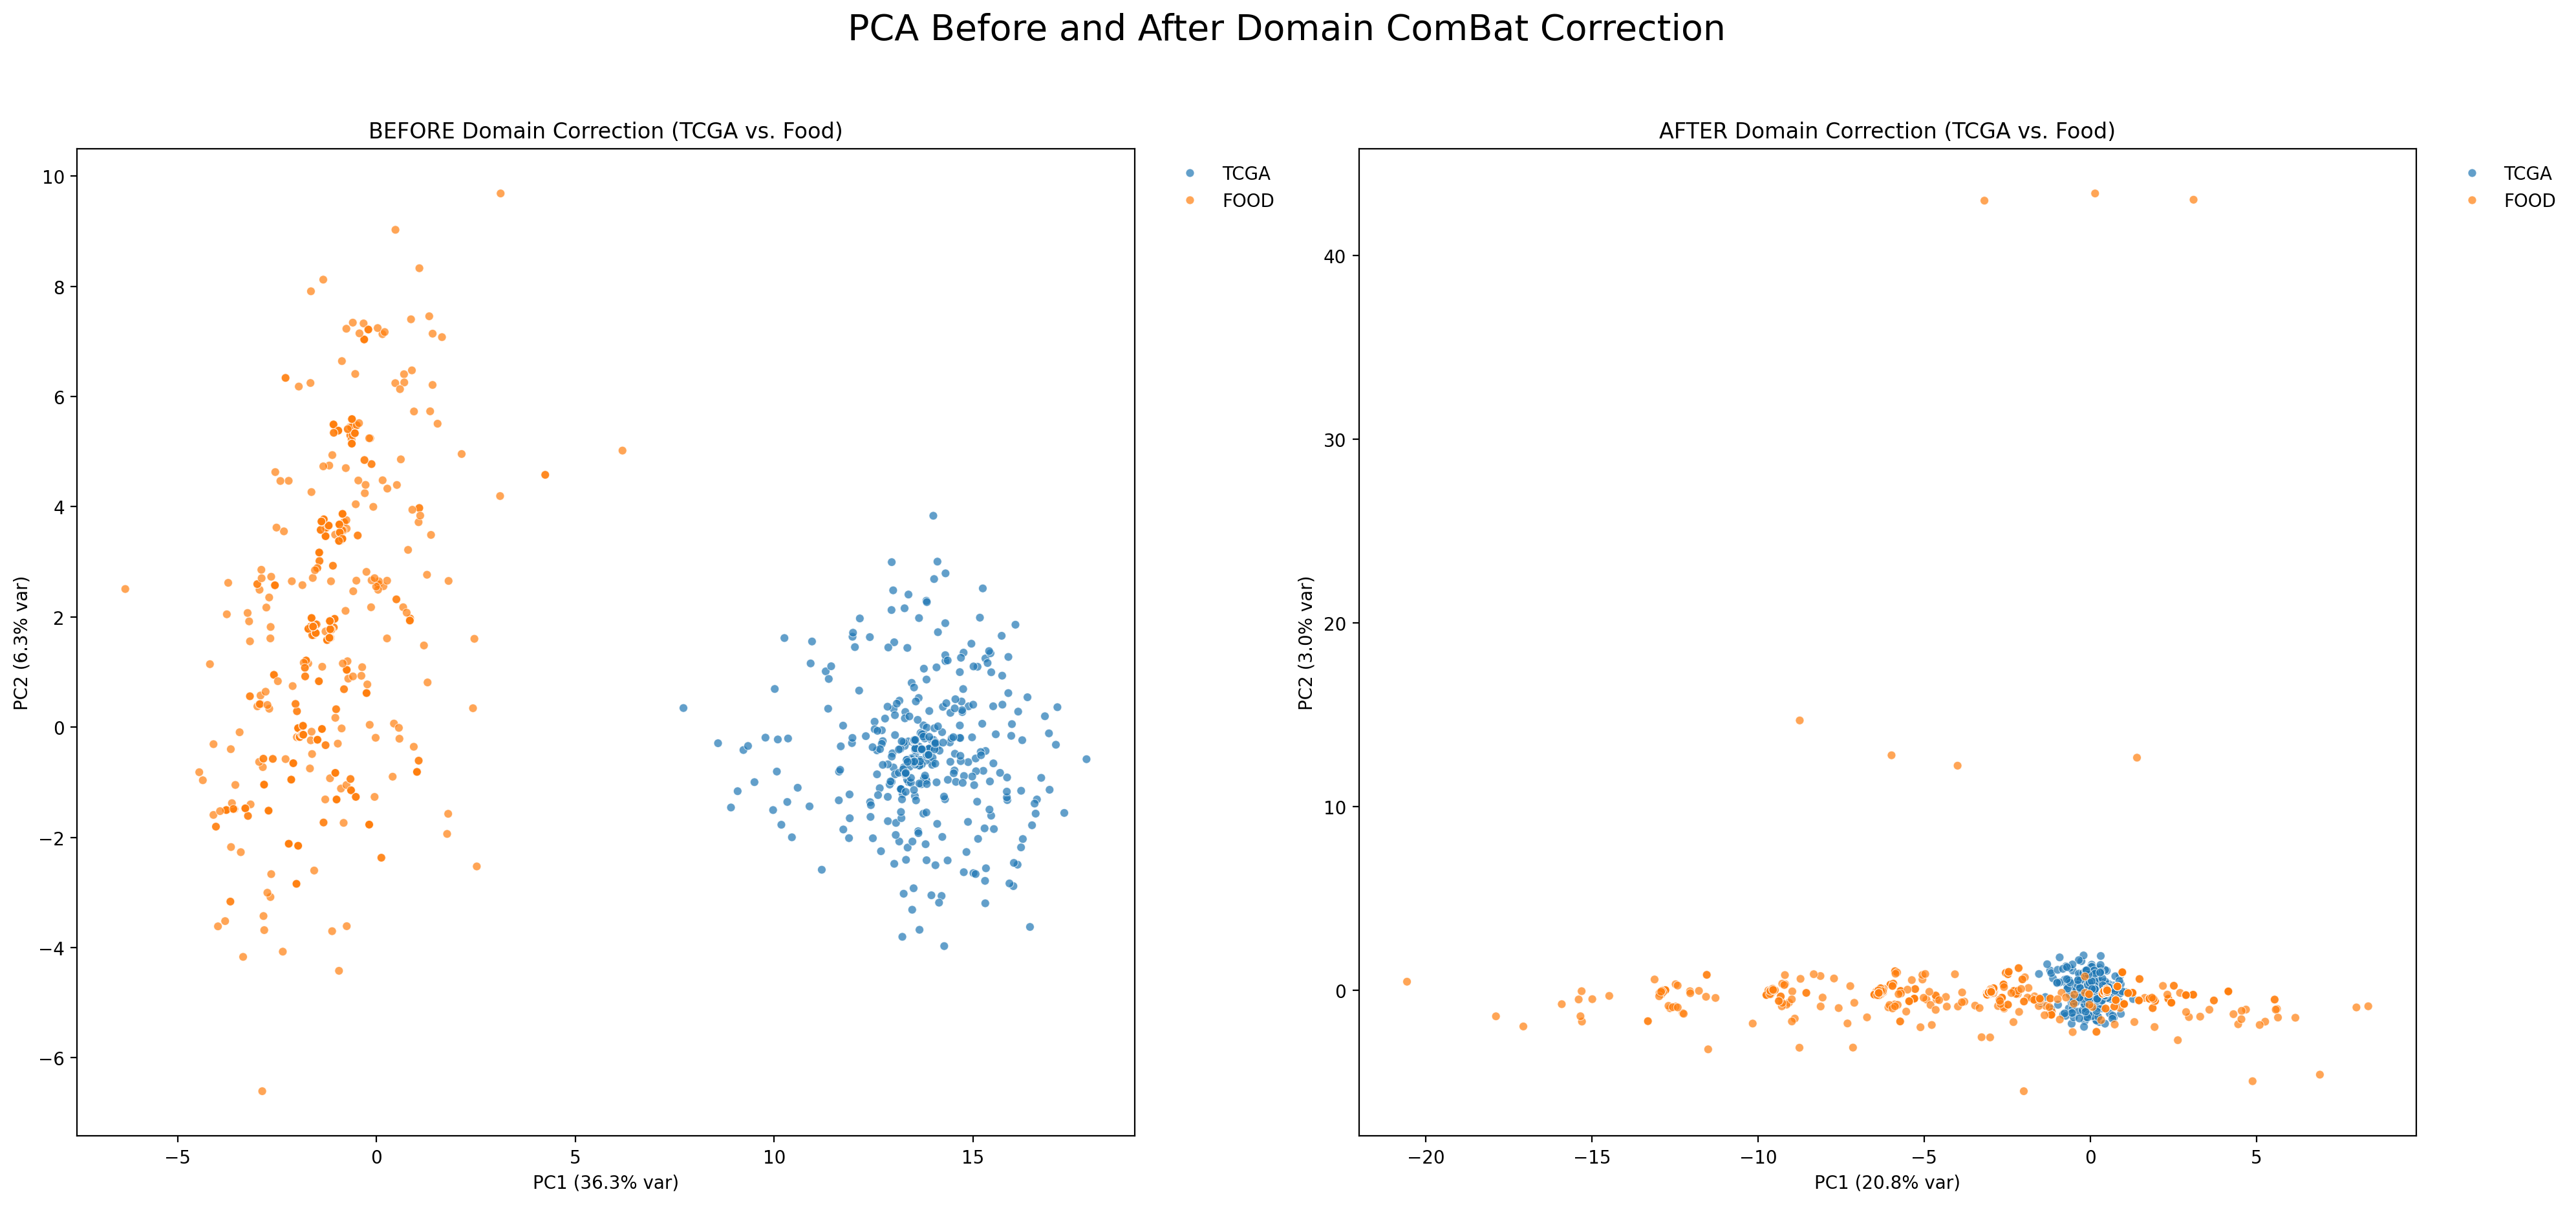

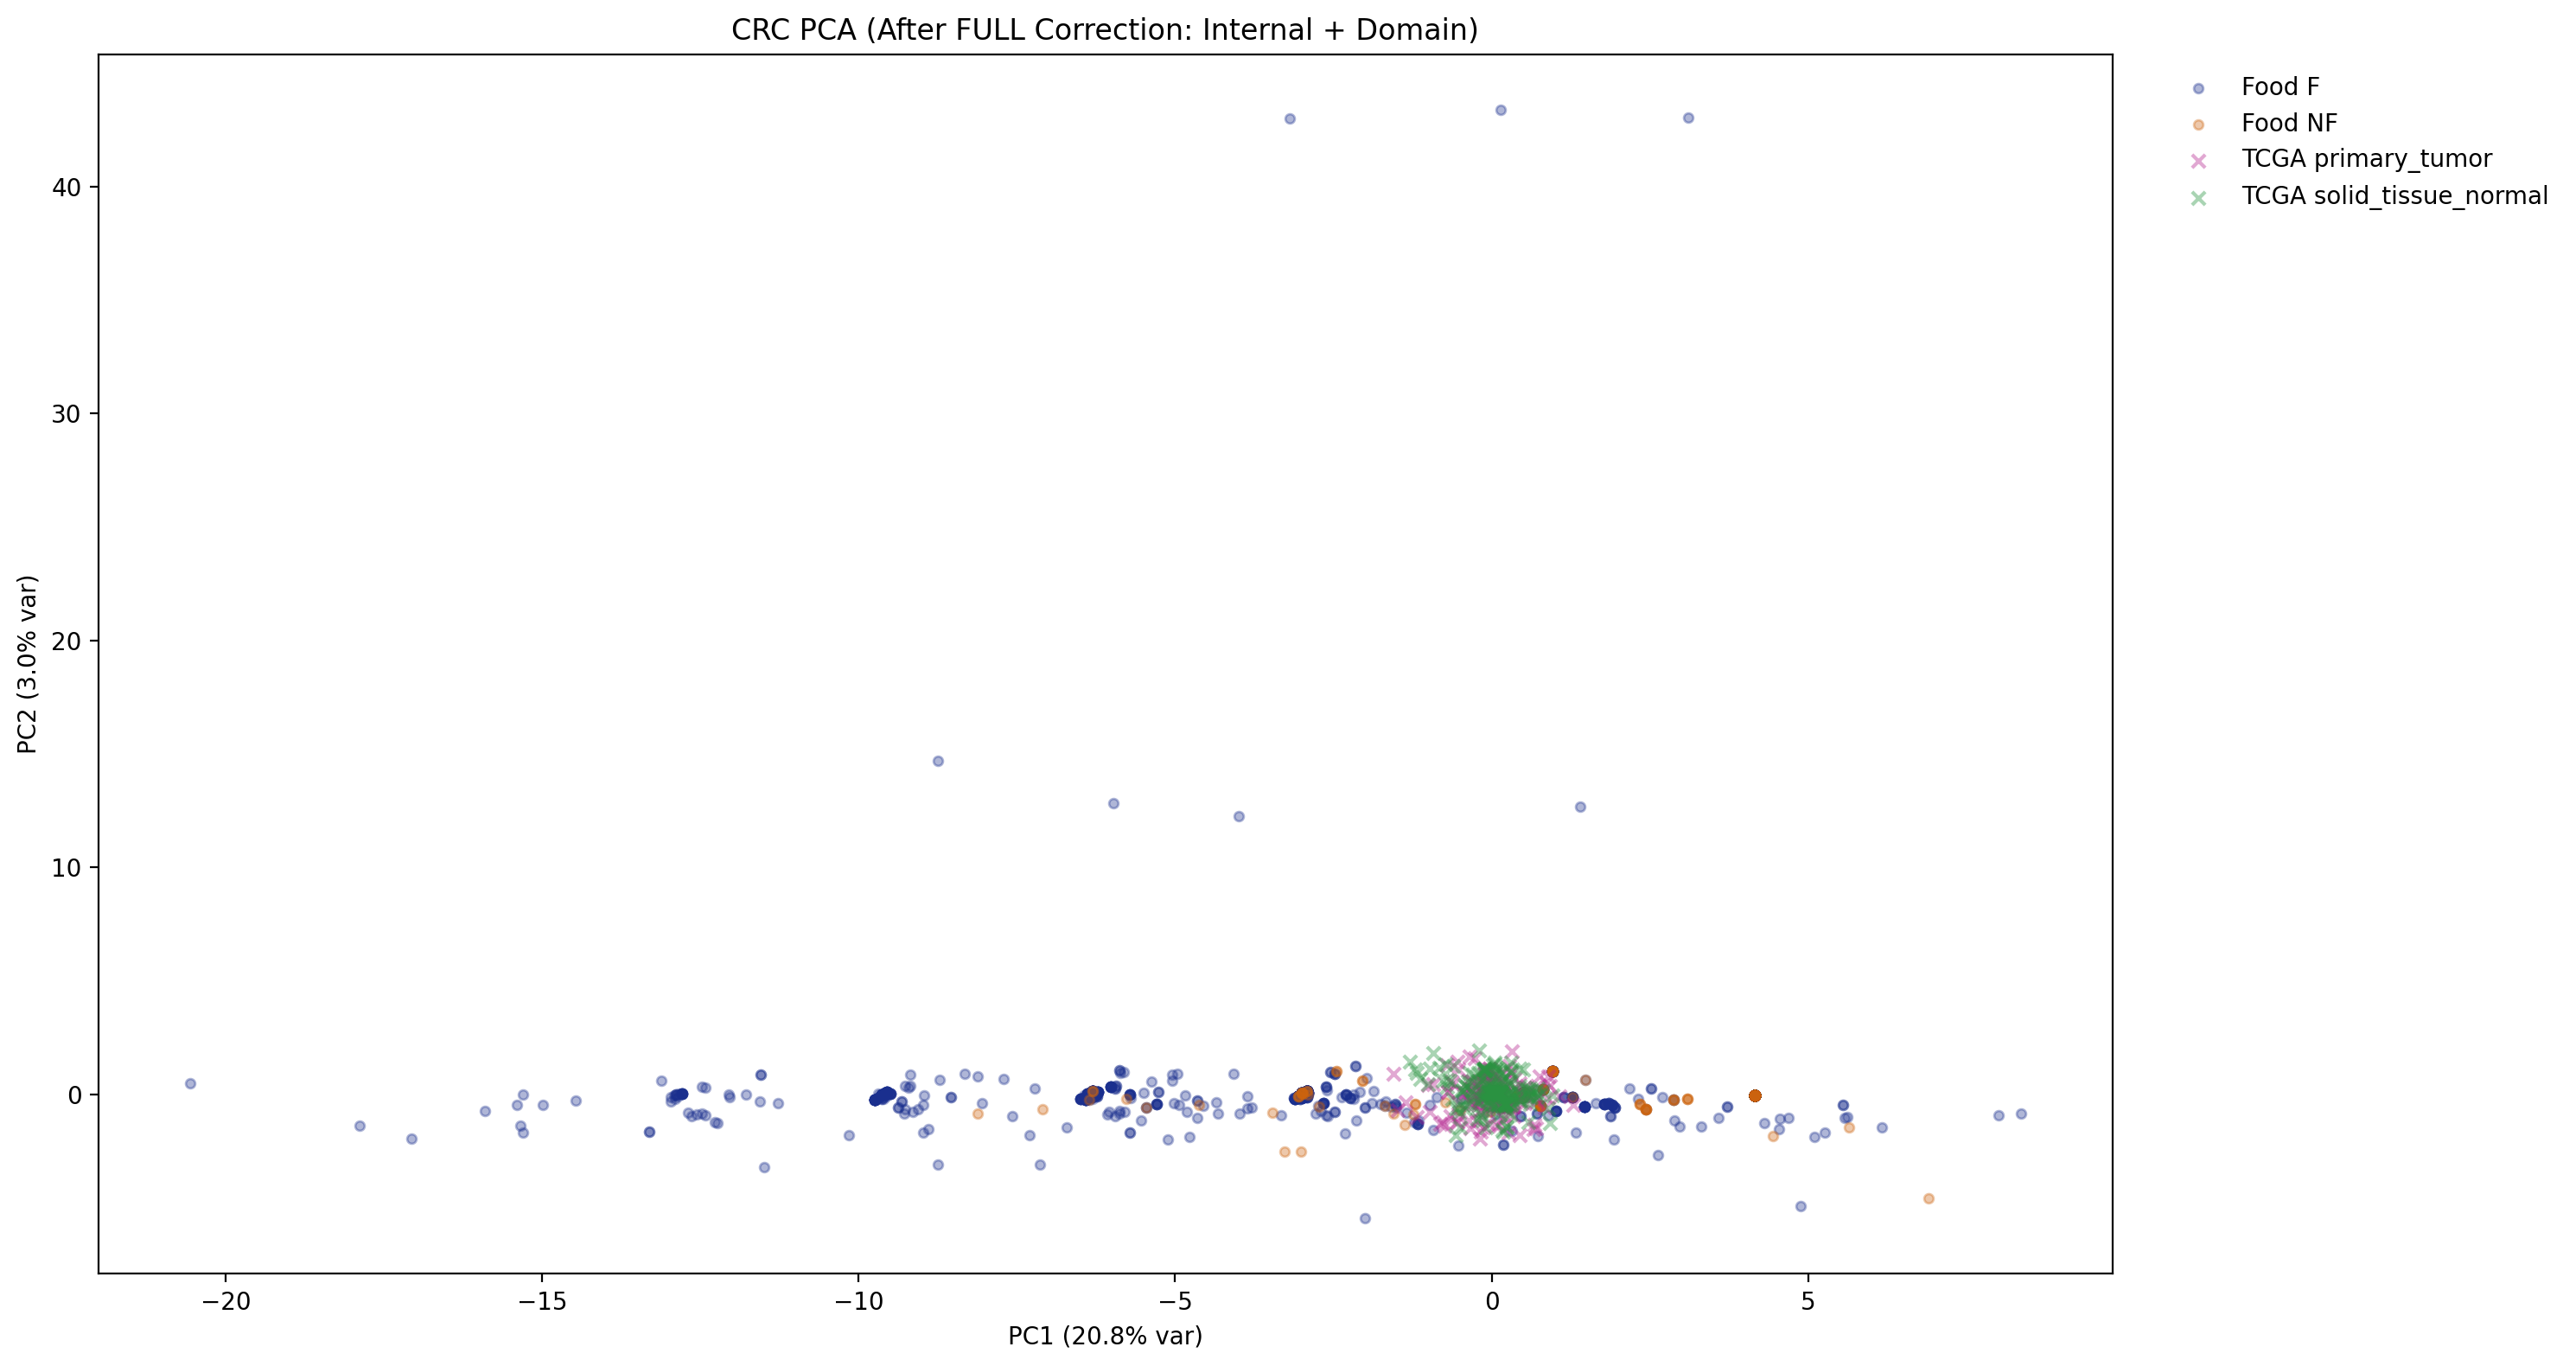

In [11]:
# --- 9. PLOTTING ---
print("--- Generating plots... ---")

# --- PLOT 1: Side-by-Side Batch Effect Diagnostic (TCGA vs. Food) ---
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9), dpi=200)

# Plot 1a: BEFORE Domain ComBat (but *after* internal TCGA correction)
# print("--- Plotting domain separation (Before)... ---")
X_after_tcga_correction = pd.concat([tcga_clr_combat1, cfmd_clr])
scaler_mid = StandardScaler()
X_mid_scaled = scaler_mid.fit_transform(X_after_tcga_correction)
pca_mid_obj = PCA(n_components=2, random_state=42)
coords_mid = pd.DataFrame(pca_mid_obj.fit_transform(X_mid_scaled), index=X_after_tcga_correction.index, columns=['PC1','PC2'])
coords_mid['domain'] = domain_batch
evr_mid = pca_mid_obj.explained_variance_ratio_
pc1_b, pc2_b = evr_mid[0]*100, evr_mid[1]*100

#########
#save x_after_tgca_correction for research question
X_after_full_correction.to_csv("final_outputs/df_shared_species_filtered.csv", index= False)


sns.scatterplot(
    data=coords_mid,
    x='PC1',
    y='PC2',
    hue='domain',
    ax=ax1,
    s=22,
    alpha=0.7
)
ax1.set_xlabel(f"PC1 ({pc1_b:.1f}% var)")
ax1.set_ylabel(f"PC2 ({pc2_b:.1f}% var)")
ax1.set_title("BEFORE Domain Correction (TCGA vs. Food)")
ax1.legend(bbox_to_anchor=(1.02,1), loc='upper left', frameon=False)

# Plot 1b: AFTER Domain ComBat
# print("--- Plotting domain separation (After)... ---")
pc1_a, pc2_a = evr_after[0]*100, evr_after[1]*100
sns.scatterplot(
    data=coords_after,
    x='PC1',
    y='PC2',
    hue='domain',
    ax=ax2,
    s=22,
    alpha=0.7
)
ax2.set_xlabel(f"PC1 ({pc1_a:.1f}% var)")
ax2.set_ylabel(f"PC2 ({pc2_a:.1f}% var)")
ax2.set_title("AFTER Domain Correction (TCGA vs. Food)")
ax2.legend(bbox_to_anchor=(1.02,1), loc='upper left', frameon=False)

fig1.suptitle('PCA Before and After Domain ComBat Correction', fontsize=20, y=1.03)
plt.tight_layout()
fig1.savefig(Path(FIGDIR) / "pca_domain_combat_diagnostic.png", bbox_inches='tight')
# plt.show() # Disabled to show all plots at the end

# --- PLOT 2: Food vs. TCGA (using FINAL fully corrected data) ---
# print("--- Plotting final biological groups... ---")
fig2 = plt.figure(figsize=(15,8), dpi=200) # Made plot larger
food_mask, tcga_mask = coords_after['domain'].eq('FOOD'), coords_after['domain'].eq('TCGA')
pc1, pc2 = evr_after[0]*100, evr_after[1]*100

# Plot Food
for f,c in {'F':"#1A2F8E",'NF':"#cd640e"}.items():
    mf = food_mask & coords_after['fermented'].fillna('NA').eq(f)
    plt.scatter(coords_after.loc[mf,'PC1'], coords_after.loc[mf,'PC2'], s=15, alpha=0.35, color=c, label=f"Food {f}")

# Plot TCGA
# Plot TCGA – nur noch zwei Typen
tcga_types = s12["sample_type_group"].reindex(coords_after.index)

for cat, c in {"primary_tumor": "#b42690",
               "solid_tissue_normal": "#2A9441"}.items():
    mt = tcga_mask & tcga_types.eq(cat)
    plt.scatter(
        coords_after.loc[mt, 'PC1'],
        coords_after.loc[mt, 'PC2'],
        s=30, color=c, alpha=0.4, marker='x',
        label=f"TCGA {cat}"
    )
plt.xlabel(f"PC1 ({pc1:.1f}% var)"); plt.ylabel(f"PC2 ({pc2:.1f}% var)")
plt.title("CRC PCA (After FULL Correction: Internal + Domain)")
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', frameon=False)
plt.tight_layout()
fig2.savefig(Path(FIGDIR) / "pca_food_vs_tcga_FULLY_corrected.png", bbox_inches='tight')
# plt.show() # Disabled to show all plots at the end

In [12]:
# --- Save final corrected coordinates ---
coords_after.to_csv(Path(OUTDIR) / "pca_coords_crc_FULLY_CORRECTED.csv", index=True)
print(f"--- Corrected PCA coordinates saved to {OUTDIR} ---")

--- Corrected PCA coordinates saved to /Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/Working_folder/output ---


## 10. PCA outlier detection

Identify extreme outliers in the PCA space (e.g. samples with very high PC2). These can correspond to technical artefacts or unusual microbiome profiles.

In [13]:
# --- 10. IDENTIFY OUTLIERS ---
print("\n--- Identifying PCA Outliers (PC2 > 10) ---")
outlier_threshold = 10
outliers = coords_after[coords_after['PC2'] > outlier_threshold]

if not outliers.empty:
    print(f"Found {len(outliers)} outliers with PC2 > {outlier_threshold}:")
    print(outliers)
else:
    print("No outliers found above PC2 > 10.")


--- Identifying PCA Outliers (PC2 > 10) ---
Found 7 outliers with PC2 > 10:
                  PC1        PC2 domain fermented    type sample_type  \
DS_103       0.142478  43.390744   FOOD         F  salami         NaN   
DS_111       3.104544  43.049795   FOOD         F  salami         NaN   
DS_112      -3.187613  42.998797   FOOD         F  salami         NaN   
FFOOD_289   -8.744000  14.705378   FOOD         F  cheese         NaN   
FFOOD_405   -3.994769  12.242758   FOOD         F  cheese         NaN   
M-29        -5.981986  12.809054   FOOD         F  cheese         NaN   
SRR19505782  1.402253  12.678740   FOOD         F   kefir         NaN   

            sequencing_center  
DS_103                     NA  
DS_111                     NA  
DS_112                     NA  
FFOOD_289                  NA  
FFOOD_405                  NA  
M-29                       NA  
SRR19505782                NA  


## 11. Survival analysis on TCGA microbiome data

Use the internally corrected TCGA matrix (`tcga_clr_combat1`) and merged clinical data to:
- filter to primary tumour samples,
- split patients into **alive** and **deceased** groups,
- run Mann–Whitney U tests per taxon,
- identify "protective" taxa (higher in survivors with FDR control),
- map these taxa back into the cFMD food data to quantify their abundance in different food types.

In [14]:
# --- 11. SURVIVAL ANALYSIS (NEW STEP) ---
print("\n--- Starting Step 11: Survival Analysis ---")
# We will use the TCGA data *after* internal correction (Step 6)
# but *before* domain correction, as this is the cleanest biological data.
# Data: tcga_clr_combat1
# Metadata: s12

# UPDATED BASED ON YOUR INPUT
SURVIVAL_COLUMN = 'alive' # Column from your 'merged_all' logic
ALIVE_VALUE = 1           # Value for survived patients
DEAD_VALUE = 0            # Value for died patients
# --- END ASSUMPTIONS ---

analysis_skipped = False
if SURVIVAL_COLUMN not in s12.columns:
    print(f"WARNING: Survival column '{SURVIVAL_COLUMN}' not found in metadata (s12).")
    print("         Check your clinical file. It was expected after the merge.")
    print("Cannot perform survival analysis. Skipping Step 11.")
    analysis_skipped = True
else:
    print(f"Using survival column: '{SURVIVAL_COLUMN}'")

if not analysis_skipped:
    # 1. Filter for Primary Tumor samples
    # We must use .str.contains, as values can be 'Primary Tumor' or 'Primary solid Tumor'
    tumor_mask = s12["sample_type_group"].eq("primary_tumor")
    tumor_indices = s12[tumor_mask].index
    print(f"Found {len(tumor_indices)} 'Primary Tumor' samples for analysis.")

    # 2. Get the microbial data (X) and survival labels (y) for these tumors
    X = tcga_clr_combat1.reindex(tumor_indices).dropna(axis=0, how='all')
    y = s12.reindex(X.index)[SURVIVAL_COLUMN]

    # 3. Separate data into "Alive" and "Dead" groups
    alive_indices = y[y == ALIVE_VALUE].index
    dead_indices = y[y == DEAD_VALUE].index

    if len(alive_indices) < 5 or len(dead_indices) < 5: # Need a minimum number for stats
        print(f"WARNING: Not enough samples for both groups.")
        print(f"Found {len(alive_indices)} '{ALIVE_VALUE}' and {len(dead_indices)} '{DEAD_VALUE}' samples.")
        print("Skipping Step 11.")
        analysis_skipped = True

if not analysis_skipped:
    X_alive = X.loc[alive_indices]
    X_dead = X.loc[dead_indices]

    print(f"Analyzing {len(X_alive)} '{ALIVE_VALUE}' samples vs. {len(X_dead)} '{DEAD_VALUE}' samples.")

    # 4. Run Differential Abundance (Mann-Whitney U-test)
    results = []
    taxa = X.columns
    for taxon in taxa:
        try:
            # Compare distributions
            stat, pval = mannwhitneyu(X_alive[taxon], X_dead[taxon], alternative='two-sided')
            
            # Calculate mean abundance
            mean_alive = X_alive[taxon].mean()
            mean_dead = X_dead[taxon].mean()
            mean_diff = mean_alive - mean_dead 
            
            results.append({
                'taxon': taxon,
                'p_value': pval,
                'mean_alive_clr': mean_alive,
                'mean_dead_clr': mean_dead,
                'mean_diff_(alive-dead)': mean_diff
            })
        except ValueError:
            # This happens if all values are identical (no variance)
            results.append({
                'taxon': taxon,
                'p_value': 1.0,
                'mean_alive_clr': X_alive[taxon].mean(),
                'mean_dead_clr': X_dead[taxon].mean(),
                'mean_diff_(alive-dead)': 0
            })

    if not results:
        print("ERROR: No results from survival analysis loop.")
        analysis_skipped = True

if not analysis_skipped:
    results_df = pd.DataFrame(results).dropna(subset=['p_value'])

    # 5. Correct for Multiple Testing (FDR)
    if not results_df.empty:
        results_df['p_adjusted'] = fdrcorrection(results_df['p_value'])[1]
    else:
        results_df['p_adjusted'] = []
        
    results_df = results_df.sort_values(by='p_value')

    print("\n--- Top 10 Taxa Associated with Survival (Unadjusted p-value) ---")
    print(results_df.head(10))

    # 6. Find "Protective Taxa" and cross-reference with food
    # Protective = significantly higher in "Alive" group
    ADJ_P_THRESHOLD = 0.10 # A common threshold for exploratory analysis
    protective_taxa = results_df[
        (results_df['p_adjusted'] < ADJ_P_THRESHOLD) &
        (results_df['mean_diff_(alive-dead)'] > 0)
    ]

    print(f"\n--- Found {len(protective_taxa)} 'Protective Taxa' (Adj. p < {ADJ_P_THRESHOLD} & higher in 'Alive') ---")

    if not protective_taxa.empty:
        print(protective_taxa[['taxon', 'p_adjusted', 'mean_diff_(alive-dead)']])
        
        # --- 7. ANSWER THE RESEARCH QUESTION ---
        protective_taxa_list = protective_taxa['taxon'].tolist()
        
        # Get mean abundance of these taxa in the food data
        # Ensure only taxa that exist in cfmd_clr are selected
        final_taxa_list = list(set(protective_taxa_list) & set(cfmd_clr.columns))
        if not final_taxa_list:
            print("No protective taxa were found in the food dataset.")
        else:
            food_abund_all = cfmd_clr[final_taxa_list].mean(axis=0).rename('mean_clr_all_food')
            
            # Break down by fermented vs. non-fermented
            food_meta_aligned = cfmd_meta.reindex(cfmd_clr.index)
            f_indices = food_meta_aligned[food_meta_aligned['fermented/non-fermented'] == 'F'].index
            nf_indices = food_meta_aligned[food_meta_aligned['fermented/non-fermented'] == 'NF'].index
            
            food_abund_f = cfmd_clr.loc[f_indices, final_taxa_list].mean(axis=0).rename('mean_clr_fermented')
            food_abund_nf = cfmd_clr.loc[nf_indices, final_taxa_list].mean(axis=0).rename('mean_clr_non_fermented')
            
            # Combine and show the final answer
            answer_df = pd.concat([
                protective_taxa.set_index('taxon').reindex(final_taxa_list)[['p_adjusted', 'mean_diff_(alive-dead)']],
                food_abund_all,
                food_abund_f,
                food_abund_nf
            ], axis=1).sort_values(by='mean_clr_fermented', ascending=False)
            
            print("\n\n--- FINAL ANSWER: Protective Taxa & Their Abundance in Food ---")
            print(answer_df)
            
            answer_df.to_csv(Path(OUTDIR) / "protective_taxa_in_food_analysis.csv", index=True)
            print(f"\nFull results saved to {OUTDIR}/protective_taxa_in_food_analysis.csv")
        
    else:
        print("No statistically significant protective taxa found at this threshold.")

print("\n--- Step 11: Survival Analysis Finished. ---")
print("--- Showing all plots... ---")
plt.show() # Show all plots at the very end
print("--- Script finished. ---")


--- Starting Step 11: Survival Analysis ---
Using survival column: 'alive'
Found 191 'Primary Tumor' samples for analysis.
Analyzing 25 '1' samples vs. 113 '0' samples.

--- Top 10 Taxa Associated with Survival (Unadjusted p-value) ---
                         taxon   p_value  mean_alive_clr  mean_dead_clr  \
64  streptococcus thermophilus  0.017981       -1.906660      -0.937786   
67      xanthomonas campestris  0.025164        0.532359      -0.830006   
11      bifidobacterium longum  0.038170       -0.920828       0.174591   
29       klebsiella pneumoniae  0.048436        9.694108       9.078288   
62        streptococcus oralis  0.051008       -0.189767       0.724432   
23        enterococcus faecium  0.102936        2.530387       3.124263   
45         priestia megaterium  0.110129       -0.102213       0.515281   
1      acinetobacter johnsonii  0.121656       -0.451600       0.173405   
46           proteus mirabilis  0.152209       -1.402095      -0.831975   
10       bifi

## 12. Machine learning: Random Forest survival model

Train a Random Forest classifier on the **internally corrected** TCGA microbiome profiles to predict patient survival status. The workflow:
1. Filter to tumour samples with valid survival labels.
2. Split into training and test sets (70/30 split, stratified).
3. Train a class-weighted Random Forest.
4. Evaluate performance (accuracy, AUC) and export feature importance.
5. Map the most important taxa back to food samples in cFMD.

In [15]:

print("\n\n--- Starting Step 12: Machine Learning Analysis ---")

# We need new imports from scikit-learn
# Import Path for saving results, if not already imported

ml_analysis_skipped = False

# --- 1. Check if we have the necessary data from the main script ---
if 'tcga_clr_combat1' not in locals():
    print("ERROR: 'tcga_clr_combat1' not found. Please run the main script first.")
    ml_analysis_skipped = True

if 's12' not in locals() or 'SURVIVAL_COLUMN' not in globals():
    print("ERROR: 's12' metadata or 'SURVIVAL_COLUMN' not defined. Please run the main script first.")
    ml_analysis_skipped = True
elif SURVIVAL_COLUMN not in s12.columns:
    print(f"ERROR: Survival column '{SURVIVAL_COLUMN}' not found in 's12'. Please run the main script first.")
    ml_analysis_skipped = True

if 'cfmd_clr' not in locals():
    print("ERROR: 'cfmd_clr' (food data) not found. Please run the main script first.")
    ml_analysis_skipped = True

if 'OUTDIR' not in globals():
    print("ERROR: 'OUTDIR' not defined. Setting a default './output' directory.")
    OUTDIR = "./output"
    Path(OUTDIR).mkdir(parents=True, exist_ok=True)


if not ml_analysis_skipped:
    # --- 2. Prepare Data (same as Step 11) ---
    # Filter for Primary Tumor samples
    # Using the fix from Step 11:
    tumor_mask = s12['sample_type'].str.lower().str.contains('primary_tumor|solid tumor')
    tumor_indices = s12[tumor_mask].index
    
    # Get the microbial data (X) and survival labels (y) for these tumors
    X_ml_all = tcga_clr_combat1.reindex(tumor_indices).dropna(axis=0, how='all')
    y_ml_all = s12.reindex(X_ml_all.index)[SURVIVAL_COLUMN]

    # --- FIX: Drop samples with missing survival data (NaN) BEFORE converting to int ---
    valid_survival_indices = y_ml_all.dropna().index
    
    X_ml = X_ml_all.loc[valid_survival_indices]
    y_ml = y_ml_all.loc[valid_survival_indices].astype(int) # Now this is safe
    # --- End of fix ---

    print(f"Using {X_ml.shape[0]} tumor samples with valid survival data for ML analysis.")
    print(f"Survival distribution:\n{y_ml.value_counts()}")

    if X_ml.shape[0] < 20: # Check if we have enough data to even run ML
        print("Not enough samples (<20) to perform ML analysis. Skipping Step 12.")
        ml_analysis_skipped = True
    elif len(y_ml.unique()) < 2:
        print(f"Only one survival class ({y_ml.unique()}) present. Cannot train a classifier. Skipping Step 12.")
        ml_analysis_skipped = True

if not ml_analysis_skipped:
    # --- 3. Split Data into Training and Testing Sets ---
    # This is critical for ML. We build the model on 70% of the data...
    X_train, X_test, y_train, y_test = train_test_split(
        X_ml, y_ml, 
        test_size=0.3, # ...and test it on 30% it has never seen.
        random_state=42, # For reproducible results
        stratify=y_ml      # Ensures both groups have similar alive/dead ratios
    )
    
    print(f"Data split into: {X_train.shape[0]} training samples, {X_test.shape[0]} testing samples.")

    # --- 4. Train a Random Forest Classifier ---
    print("Training Random Forest model...")
    # n_estimators=500: Builds 500 "trees". More is generally stabler.
    # class_weight='balanced': Helps the model deal with unbalanced data (if you have few 'Dead' samples)
    model = RandomForestClassifier(n_estimators=500, random_state=42, class_weight='balanced', n_jobs=-1)
    model.fit(X_train, y_train)
    
    # --- 5. Evaluate the Model ---
    y_pred = model.predict(X_test)
    accuracy = metrics.accuracy_score(y_test, y_pred)
    # AUC is a better metric for unbalanced classes. 0.5 = random, 1.0 = perfect.
    try:
        auc = metrics.roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    except ValueError:
        auc = -1 # Handle cases if only one class is present in test set

    print(f"\n--- Model Performance on Test Set ---")
    print(f"Accuracy: {accuracy*100:.2f}%")
    print(f"AUC (Area Under Curve): {auc:.3f}")
    
    if auc < 0.6:
        print("Model performance is low (AUC < 0.6). The 'important' features may not be reliable.")
    else:
        print("Model performance is good. Extracting important features.")

    # --- 6. Get Feature Importances ---
    # This is the "answer" from the model
    importances = model.feature_importances_
    
    # Create a DataFrame of taxa and their importance scores
    feature_importance_df = pd.DataFrame({
        'taxon': X_ml.columns,
        'importance': importances
    }).sort_values(by='importance', ascending=False)
    
    print("\n--- Top 20 Most Important Taxa (Features) for Predicting Survival ---")
    print(feature_importance_df.head(20))
    
    # --- 7. ANSWER THE RESEARCH QUESTION ---
    # Now we cross-reference *this* list with the food data
    
    # Get the list of the top 50 most important taxa
    candidate_taxa_list = feature_importance_df.head(50)['taxon'].tolist()
    
    # Check mean abundance of these taxa in food
    final_taxa_list_ml = list(set(candidate_taxa_list) & set(cfmd_clr.columns))
    
    if not final_taxa_list_ml:
        print("\nNone of the top 50 important taxa were found in the food dataset.")
    else:
        print(f"\n--- Cross-Referencing Top 50 Important Taxa with Food Data ---")
        
        # Get mean abundance in food
        food_abund_all_ml = cfmd_clr[final_taxa_list_ml].mean(axis=0).rename('mean_clr_all_food')
        
        # Break down by fermented vs. non-fermented
        food_meta_aligned_ml = cfmd_meta.reindex(cfmd_clr.index)
        f_indices_ml = food_meta_aligned_ml[food_meta_aligned_ml['fermented/non-fermented'] == 'F'].index
        nf_indices_ml = food_meta_aligned_ml[food_meta_aligned_ml['fermented/non-fermented'] == 'NF'].index
        
        food_abund_f_ml = cfmd_clr.loc[f_indices_ml, final_taxa_list_ml].mean(axis=0).rename('mean_clr_fermented')
        food_abund_nf_ml = cfmd_clr.loc[nf_indices_ml, final_taxa_list_ml].mean(axis=0).rename('mean_clr_non_fermented')
        
        # Combine and show the final answer
        answer_df_ml = pd.concat([
            feature_importance_df.set_index('taxon').reindex(final_taxa_list_ml)[['importance']],
            food_abund_all_ml,
            food_abund_f_ml,
            food_abund_nf_ml
        ], axis=1).sort_values(by='importance', ascending=False)
        
        print("\n\n--- FINAL ML ANSWER: Importance for Survival & Abundance in Food ---")
        print(answer_df_ml)
        
        # Save to a new file
        ml_answer_path = Path(OUTDIR) / "ml_protective_taxa_in_food_analysis.csv"
        answer_df_ml.to_csv(ml_answer_path, index=True)
        print(f"\nML analysis results saved to {ml_answer_path}")

print("\n--- Step 12: Machine Learning Analysis Finished. ---")



--- Starting Step 12: Machine Learning Analysis ---
Using 138 tumor samples with valid survival data for ML analysis.
Survival distribution:
alive
0    113
1     25
Name: count, dtype: int64
Data split into: 96 training samples, 42 testing samples.
Training Random Forest model...

--- Model Performance on Test Set ---
Accuracy: 76.19%
AUC (Area Under Curve): 0.574
Model performance is low (AUC < 0.6). The 'important' features may not be reliable.

--- Top 20 Most Important Taxa (Features) for Predicting Survival ---
                           taxon  importance
10         bifidobacterium breve    0.051993
11        bifidobacterium longum    0.042774
29         klebsiella pneumoniae    0.040162
67        xanthomonas campestris    0.033683
21       enterobacter hormaechei    0.027053
62          streptococcus oralis    0.026841
64    streptococcus thermophilus    0.024950
45           priestia megaterium    0.024521
27       hungatella xylanolytica    0.020366
66               vibrio ch

## 13. ML performance visualisation (Random Forest)

Visual diagnostic plots for the Random Forest survival model, including ROC curves, calibration-style plots and comparison of train vs test AUC to assess overfitting.



--- Starting Step 13: ML Performance Visualization ---
Generating Confusion Matrix for Test Set...


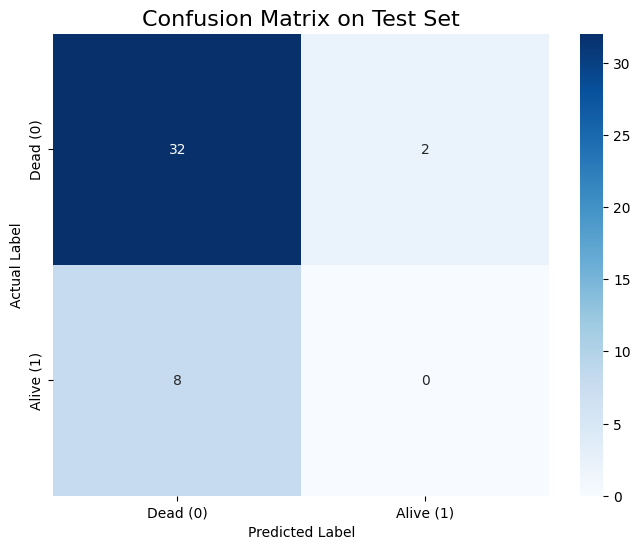


--- Classification Report on Test Set ---
              precision    recall  f1-score   support

    Dead (0)       0.80      0.94      0.86        34
   Alive (1)       0.00      0.00      0.00         8

    accuracy                           0.76        42
   macro avg       0.40      0.47      0.43        42
weighted avg       0.65      0.76      0.70        42

Balanced Accuracy: 47.06%
----------------------------------------
Generating ROC Curve (Train vs. Test) to check for overfitting...


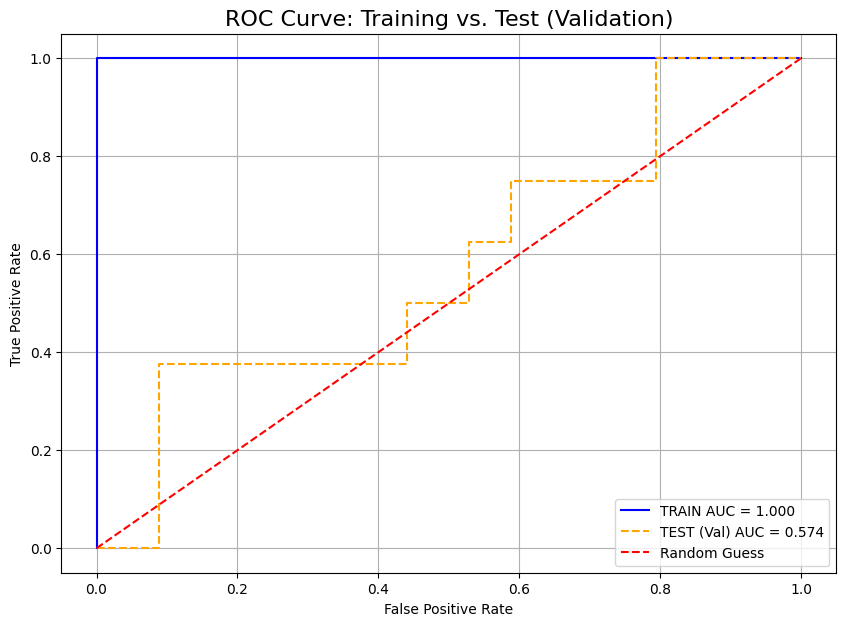

INFO: The Train AUC (1.000) is much higher than the Test AUC (0.574).
This indicates the model might be 'overfitting' (memorizing) the training data.

--- Step 13: ML Visualization Finished. ---


In [16]:

print("\n\n--- Starting Step 13: ML Performance Visualization ---")

# We need new imports
# --- NEW IMPORTS ---

vis_skipped = False

# --- 1. Check if we have the necessary data from the main script ---
if 'model' not in locals():
    print("ERROR: 'model' not found. Please run 'Step 12: Machine Learning Analysis' first.")
    vis_skipped = True

if 'X_train' not in locals() or 'y_train' not in locals() or 'X_test' not in locals() or 'y_test' not in locals():
    print("ERROR: Train/Test data not found. Please run 'Step 12: Machine Learning Analysis' first.")
    vis_skipped = True
    
if 'y_pred' not in locals():
    # y_pred was calculated in Step 12, but we can recalculate if needed
    if 'model' in locals() and 'X_test' in locals():
         y_pred = model.predict(X_test)
    else:
         print("ERROR: 'y_pred' not found and cannot be recalculated. Run Step 12.")
         vis_skipped = True

# We also need the survival value definitions from the main script
if 'ALIVE_VALUE' not in globals() or 'DEAD_VALUE' not in globals():
    print("ERROR: 'ALIVE_VALUE' and 'DEAD_VALUE' not found. Please re-run the main script (run_combat_on_merged_data.py) first.")
    vis_skipped = True


if not vis_skipped:
    # Get the labels (e.g., 0='Dead', 1='Alive')
    labels = [f"Dead ({DEAD_VALUE})", f"Alive ({ALIVE_VALUE})"]
    target_names = [f"Dead ({DEAD_VALUE})", f"Alive ({ALIVE_VALUE})"]

    # --- PLOT 1: Confusion Matrix (The 'sns' plot) ---
    print("Generating Confusion Matrix for Test Set...")
    
    cm = metrics.confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.title('Confusion Matrix on Test Set', fontsize=16)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # --- NEW: PLOT 1.5: Classification Report ---
    print("\n--- Classification Report on Test Set ---")
    # This report gives you precision, recall, and f1-score for BOTH classes
    report = classification_report(y_test, y_pred, target_names=target_names)
    print(report)
    
    # Also print the Balanced Accuracy
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    print(f"Balanced Accuracy: {bal_acc*100:.2f}%")
    print("-" * 40)


    # --- PLOT 2: ROC Curve (Train vs. Test/Validation) ---
    print("Generating ROC Curve (Train vs. Test) to check for overfitting...")

    # Get prediction probabilities
    y_pred_proba_test = model.predict_proba(X_test)[:, 1]
    y_pred_proba_train = model.predict_proba(X_train)[:, 1]
    
    # Calculate ROC data
    fpr_test, tpr_test, _ = metrics.roc_curve(y_test, y_pred_proba_test)
    auc_test = metrics.roc_auc_score(y_test, y_pred_proba_test)
    
    fpr_train, tpr_train, _ = metrics.roc_curve(y_train, y_pred_proba_train)
    auc_train = metrics.roc_auc_score(y_train, y_pred_proba_train)

    # Plot
    plt.figure(figsize=(10, 7))
    plt.plot(fpr_train, tpr_train, label=f"TRAIN AUC = {auc_train:.3f}", color='blue')
    plt.plot(fpr_test, tpr_test, label=f"TEST (Val) AUC = {auc_test:.3f}", color='orange', linestyle='--')
    plt.plot([0, 1], [0, 1], 'r--', label='Random Guess') # 45-degree line
    
    plt.title('ROC Curve: Training vs. Test (Validation)', fontsize=16)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.show()

    if (auc_train - auc_test) > 0.15:
        print(f"INFO: The Train AUC ({auc_train:.3f}) is much higher than the Test AUC ({auc_test:.3f}).")
        print("This indicates the model might be 'overfitting' (memorizing) the training data.")
    else:
        print(f"INFO: The Train AUC ({auc_train:.3f}) and Test AUC ({auc_test:.3f}) are close.")
        print("This is a good sign that the model is generalizing well.")


print("\n--- Step 13: ML Visualization Finished. ---")

## 14. Machine learning: CatBoost survival model

Repeat the survival ML analysis using **CatBoost**, which can handle non-linear effects and class imbalance more flexibly. Steps:
1. Reuse the same tumour subset and survival labels.
2. Train/test split (70/30, stratified).
3. Train a CatBoost classifier with imbalance-aware weighting.
4. Evaluate performance (accuracy, balanced accuracy, AUC, recall, F1).
5. Extract CatBoost feature importance and link important taxa to their abundance in food.

In [17]:

print("\n\n--- Starting Step 12.A: Machine Learning Analysis (with CatBoost) ---")

# We need new imports from scikit-learn
# Import Path for saving results, if not already imported

# --- *** NEW MODEL IMPORT *** ---

# --- NEW IMPORTS for better metrics ---


ml_analysis_skipped = False

# --- 1. Check if we have the necessary data from the main script ---
if 'tcga_clr_combat1' not in locals():
    print("ERROR: 'tcga_clr_combat1' not found. Please run the main script first.")
    ml_analysis_skipped = True

if 's12' not in locals() or 'SURVIVAL_COLUMN' not in globals():
    print("ERROR: 's12' metadata or 'SURVIVAL_COLUMN' not defined. Please run the main script first.")
    ml_analysis_skipped = True
elif SURVIVAL_COLUMN not in s12.columns:
    print(f"ERROR: Survival column '{SURVIVAL_COLUMN}' not found in 's12'. Please run the main script first.")
    ml_analysis_skipped = True

if 'cfmd_clr' not in locals():
    print("ERROR: 'cfmd_clr' (food data) not found. Please run the main script first.")
    ml_analysis_skipped = True

if 'OUTDIR' not in globals():
    print("ERROR: 'OUTDIR' not defined. Setting a default './output' directory.")
    OUTDIR = "./output"
    Path(OUTDIR).mkdir(parents=True, exist_ok=True)
    
# We also need the survival value definitions from the main script
if 'ALIVE_VALUE' not in globals() or 'DEAD_VALUE' not in globals():
    print("ERROR: 'ALIVE_VALUE' and 'DEAD_VALUE' not found. Please re-run the main script (run_combat_on_merged_data.py) first.")
    ml_analysis_skipped = True


if not ml_analysis_skipped:
    # --- 2. Prepare Data (same as Step 11) ---
    # Filter for Primary Tumor samples
    # Using the fix from Step 11:
    tumor_mask = s12['sample_type'].str.lower().str.contains('primary_tumor|solid tumor')
    tumor_indices = s12[tumor_mask].index
    
    # Get the microbial data (X) and survival labels (y) for these tumors
    X_ml_all = tcga_clr_combat1.reindex(tumor_indices).dropna(axis=0, how='all')
    y_ml_all = s12.reindex(X_ml_all.index)[SURVIVAL_COLUMN]

    # --- FIX: Drop samples with missing survival data (NaN) BEFORE converting to int ---
    valid_survival_indices = y_ml_all.dropna().index
    
    X_ml = X_ml_all.loc[valid_survival_indices]
    y_ml = y_ml_all.loc[valid_survival_indices].astype(int) # Now this is safe
    # --- End of fix ---

    print(f"Using {X_ml.shape[0]} tumor samples with valid survival data for ML analysis.")
    print(f"Survival distribution:\n{y_ml.value_counts()}")
    
    # --- *** NEW: Calculate imbalance weight for CatBoost *** ---
    class_counts = y_ml.value_counts()
    try:
        scale_pos_weight = class_counts[DEAD_VALUE] / class_counts[ALIVE_VALUE]
        print(f"Calculated scale_pos_weight for imbalance: {scale_pos_weight:.2f}")
    except ZeroDivisionError:
        print("Error: 'ALIVE_VALUE' count is zero. Cannot calculate scale_pos_weight.")
        scale_pos_weight = 1 # Default to 1
        ml_analysis_skipped = True
    except KeyError:
        print("Error: Could not find both 'ALIVE' and 'DEAD' values in y_ml. Skipping ML.")
        ml_analysis_skipped = True

    if X_ml.shape[0] < 20: # Check if we have enough data to even run ML
        print("Not enough samples (<20) to perform ML analysis. Skipping Step 12.")
        ml_analysis_skipped = True
    elif len(y_ml.unique()) < 2:
        print(f"Only one survival class ({y_ml.unique()}) present. Cannot train a classifier. Skipping Step 12.")
        ml_analysis_skipped = True

if not ml_analysis_skipped:
    # --- 3. Split Data into Training and Testing Sets ---
    # This is critical for ML. We build the model on 70% of the data...
    X_train, X_test, y_train, y_test = train_test_split(
        X_ml, y_ml, 
        test_size=0.3, # ...and test it on 30% it has never seen.
        random_state=42, # For reproducible results
        stratify=y_ml      # Ensures both groups have similar alive/dead ratios
    )
    
    # --- *** NEW: Create a Validation set for Early Stopping *** ---
    # We split the training data again to get a validation set
    # This will be used to monitor for overfitting
    X_train_sub, X_val, y_train_sub, y_val = train_test_split(
        X_train, y_train,
        test_size=0.2, # 20% of the training data
        random_state=42,
        stratify=y_train
    )

    print(f"Data split into: {X_train_sub.shape[0]} training, {X_val.shape[0]} validation, {X_test.shape[0]} testing samples.")

    # --- 4. Train a CatBoost Classifier ---
    print("Building and training CatBoost model...")
    
    # --- *** NEW MODEL DEFINITION *** ---
    model_catboost = CatBoostClassifier(
        iterations=1000,          # Max number of trees (will stop early)
        random_seed=42,
        scale_pos_weight=scale_pos_weight, # Handles class imbalance
        early_stopping_rounds=50, # Stops training if validation score doesn't improve for 50 rounds
        verbose=False             # Hides the training logs
    )

    print("Training CatBoost model with early stopping...")
    model_catboost.fit(
        X_train_sub, y_train_sub,
        eval_set=(X_val, y_val), # Use validation set to monitor for overfitting
        verbose=False
    ) 
    
    print(f"Model training complete. Stopped at iteration: {model_catboost.get_best_iteration()}")
    
    # --- 5. Evaluate the Model ---
    y_pred_catboost = model_catboost.predict(X_test)
    
    # --- Calculate all metrics ---
    accuracy = metrics.accuracy_score(y_test, y_pred_catboost)
    bal_accuracy = balanced_accuracy_score(y_test, y_pred_catboost)
    recall = recall_score(y_test, y_pred_catboost, pos_label=ALIVE_VALUE) 
    f1 = f1_score(y_test, y_pred_catboost, pos_label=ALIVE_VALUE) 
    
    try:
        auc = metrics.roc_auc_score(y_test, model_catboost.predict_proba(X_test)[:, 1])
    except ValueError:
        auc = -1 

    print(f"\n--- CatBoost Model Performance on Test Set ---")
    print(f"Overall Accuracy:       {accuracy*100:.2f}%")
    print(f"Balanced Accuracy:    {bal_accuracy*100:.2f}% (Good for imbalance)")
    print(f"AUC (Area Under Curve): {auc:.3f}")
    print(f"RECALL (Alive={ALIVE_VALUE}):      {recall:.3f} (Of all 'Alive' samples, model found this fraction)")
    print(f"F1-Score (Alive={ALIVE_VALUE}):    {f1:.3f} (Harmonic mean of precision and recall)")
    
    if auc < 0.6:
        print("Model performance is still low (AUC < 0.6). The 'important' features may not be reliable.")
    else:
        print("Model performance has improved! Extracting important features.")

    # --- 6. Get Feature Importances ---
    # --- *** NEW: CatBoost method for feature importance *** ---
    importances_catboost = model_catboost.get_feature_importance()
    
    # Create a DataFrame of taxa and their importance scores
    feature_importance_df_catboost = pd.DataFrame({
        'taxon': X_ml.columns,
        'importance': importances_catboost
    }).sort_values(by='importance', ascending=False)
    
    print("\n--- Top 20 Most Important Taxa (Features) for Predicting Survival (CatBoost) ---")
    print(feature_importance_df_catboost.head(20))
    
    # --- 7. ANSWER THE RESEARCH QUESTION ---
    # Now we cross-reference *this* list with the food data
    
    # Get the list of the top 30 most important taxa
    candidate_taxa_list_catboost = feature_importance_df_catboost.head(30)['taxon'].tolist()
    
    # Check mean abundance of these taxa in food
    final_taxa_list_ml = list(set(candidate_taxa_list_catboost) & set(cfmd_clr.columns))
    
    if not final_taxa_list_ml:
        print("\nNone of the top 30 important taxa were found in the food dataset.")
    else:
        print(f"\n--- Cross-Referencing Top 30 Important Taxa with Food Data ---")
        
        # Get mean abundance in food
        food_abund_all_ml = cfmd_clr[final_taxa_list_ml].mean(axis=0).rename('mean_clr_all_food')
        
        # Break down by fermented vs. non-fermented
        food_meta_aligned_ml = cfmd_meta.reindex(cfmd_clr.index)
        f_indices_ml = food_meta_aligned_ml[food_meta_aligned_ml['fermented/non-fermented'] == 'F'].index
        nf_indices_ml = food_meta_aligned_ml[food_meta_aligned_ml['fermented/non-fermented'] == 'NF'].index
        
        food_abund_f_ml = cfmd_clr.loc[f_indices_ml, final_taxa_list_ml].mean(axis=0).rename('mean_clr_fermented')
        food_abund_nf_ml = cfmd_clr.loc[nf_indices_ml, final_taxa_list_ml].mean(axis=0).rename('mean_clr_non_fermented')
        
        # Combine and show the final answer
        answer_df_ml_catboost = pd.concat([
            feature_importance_df_catboost.set_index('taxon').reindex(final_taxa_list_ml)[['importance']],
            food_abund_all_ml,
            food_abund_f_ml,
            food_abund_nf_ml
        ], axis=1).sort_values(by='importance', ascending=False)
        
        print("\n\n--- FINAL ML ANSWER (CatBoost): Importance for Survival & Abundance in Food ---")
        print(answer_df_ml_catboost)
        
        # Save to a new file
        ml_answer_path = Path(OUTDIR) / "ml_protective_taxa_in_food_analysis_CATBOOST.csv"
        answer_df_ml_catboost.to_csv(ml_answer_path, index=True)
        print(f"\nML analysis results saved to {ml_answer_path}")

print("\n--- Step 12.A: Machine Learning Analysis (CatBoost) Finished. ---")



--- Starting Step 12.A: Machine Learning Analysis (with CatBoost) ---
Using 138 tumor samples with valid survival data for ML analysis.
Survival distribution:
alive
0    113
1     25
Name: count, dtype: int64
Calculated scale_pos_weight for imbalance: 4.52
Data split into: 76 training, 20 validation, 42 testing samples.
Building and training CatBoost model...
Training CatBoost model with early stopping...
Model training complete. Stopped at iteration: 0

--- CatBoost Model Performance on Test Set ---
Overall Accuracy:       69.05%
Balanced Accuracy:    52.21% (Good for imbalance)
AUC (Area Under Curve): 0.557
RECALL (Alive=1):      0.250 (Of all 'Alive' samples, model found this fraction)
F1-Score (Alive=1):    0.235 (Harmonic mean of precision and recall)
Model performance is still low (AUC < 0.6). The 'important' features may not be reliable.

--- Top 20 Most Important Taxa (Features) for Predicting Survival (CatBoost) ---
                            taxon  importance
34  lactiplan

## 15. ML performance visualisation (CatBoost)

Visualise the performance of the CatBoost survival model, similar to the Random Forest case, with a focus on ROC curves and train–test comparison.

Generating Confusion Matrix for Test Set (CatBoost)...


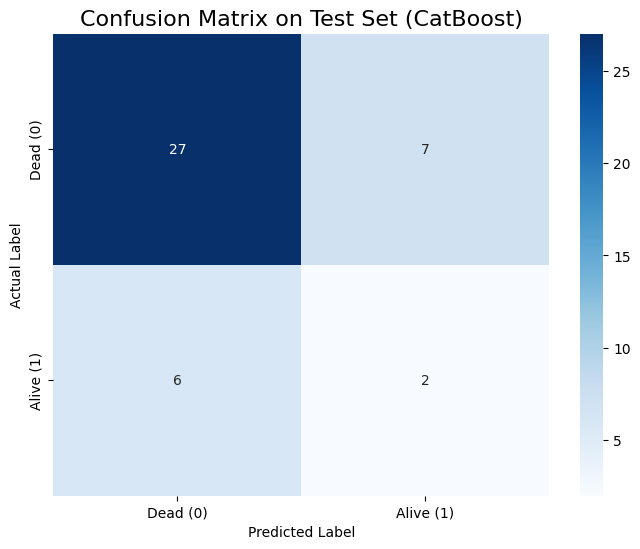


--- Classification Report on Test Set (CatBoost) ---
              precision    recall  f1-score   support

    Dead (0)       0.82      0.79      0.81        34
   Alive (1)       0.22      0.25      0.24         8

    accuracy                           0.69        42
   macro avg       0.52      0.52      0.52        42
weighted avg       0.70      0.69      0.70        42

Balanced Accuracy: 52.21%
----------------------------------------
Generating ROC Curve (Train vs. Test) to check for overfitting (CatBoost)...


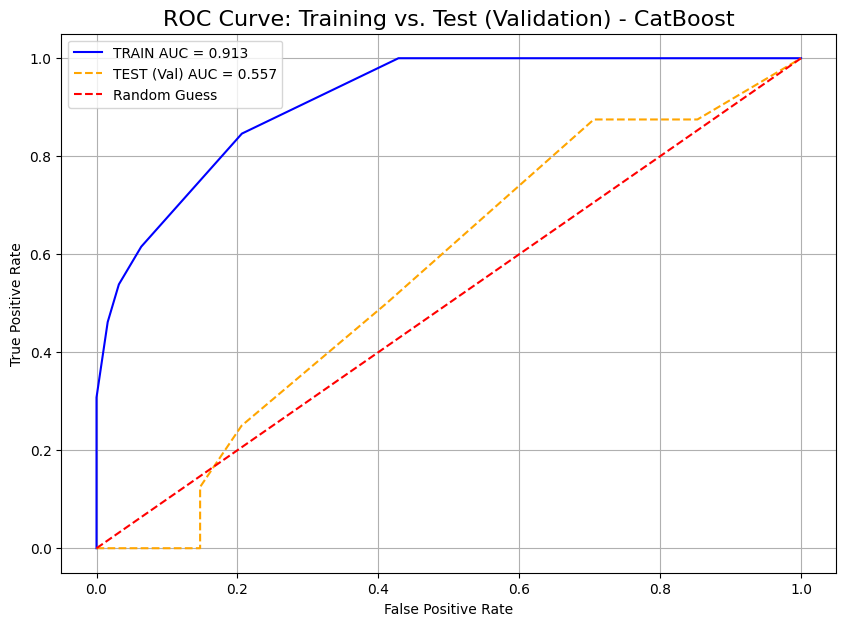

INFO: The Train AUC (0.913) is much higher than the Test AUC (0.557).
This indicates the model might be 'overfitting' (memorizing) the training data.

--- Step 13.A: CatBoost ML isualization Finished. ---


In [18]:
vis_skipped = False

# --- 1. Check if we have the necessary data from the CatBoost script ---
if 'model_catboost' not in locals():
    print("ERROR: 'model_catboost' not found. Please run 'Step 12.A: CatBoost ML Analysis' first.")
    vis_skipped = True

# We need the *sub-set* of training data that CatBoost was *actually* trained on
if 'X_train_sub' not in locals() or 'y_train_sub' not in locals() or 'X_test' not in locals() or 'y_test' not in locals():
    print("ERROR: Train/Test data not found. Please run 'Step 12.A: CatBoost ML Analysis' first.")
    vis_skipped = True
    
if 'y_pred_catboost' not in locals():
    # y_pred_catboost was calculated in Step 12.A, but we can recalculate if needed
    if 'model_catboost' in locals() and 'X_test' in locals():
         y_pred_catboost = model_catboost.predict(X_test)
    else:
         print("ERROR: 'y_pred_catboost' not found and cannot be recalculated. Run Step 12.A.")
         vis_skipped = True

# We also need the survival value definitions from the main script
if 'ALIVE_VALUE' not in globals() or 'DEAD_VALUE' not in globals():
    print("ERROR: 'ALIVE_VALUE' and 'DEAD_VALUE' not found. Please re-run the main script (run_combat_on_merged_data.py) first.")
    vis_skipped = True


if not vis_skipped:
    # Get the labels (e.g., 0='Dead', 1='Alive')
    labels = [f"Dead ({DEAD_VALUE})", f"Alive ({ALIVE_VALUE})"]
    target_names = [f"Dead ({DEAD_VALUE})", f"Alive ({ALIVE_VALUE})"]

    # --- PLOT 1: Confusion Matrix (The 'sns' plot) ---
    print("Generating Confusion Matrix for Test Set (CatBoost)...")
    
    cm = metrics.confusion_matrix(y_test, y_pred_catboost)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.title('Confusion Matrix on Test Set (CatBoost)', fontsize=16)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # --- NEW: PLOT 1.5: Classification Report ---
    print("\n--- Classification Report on Test Set (CatBoost) ---")
    # This report gives you precision, recall, and f1-score for BOTH classes
    report = classification_report(y_test, y_pred_catboost, target_names=target_names)
    print(report)
    
    # Also print the Balanced Accuracy
    bal_acc = balanced_accuracy_score(y_test, y_pred_catboost)
    print(f"Balanced Accuracy: {bal_acc*100:.2f}%")
    print("-" * 40)


    # --- PLOT 2: ROC Curve (Train vs. Test/Validation) ---
    print("Generating ROC Curve (Train vs. Test) to check for overfitting (CatBoost)...")

    # Get prediction probabilities
    y_pred_proba_test = model_catboost.predict_proba(X_test)[:, 1]
    # We compare against the actual training set, X_train_sub
    y_pred_proba_train = model_catboost.predict_proba(X_train_sub)[:, 1]
    
    # Calculate ROC data
    fpr_test, tpr_test, _ = metrics.roc_curve(y_test, y_pred_proba_test)
    auc_test = metrics.roc_auc_score(y_test, y_pred_proba_test)
    
    fpr_train, tpr_train, _ = metrics.roc_curve(y_train_sub, y_pred_proba_train)
    auc_train = metrics.roc_auc_score(y_train_sub, y_pred_proba_train)

    # Plot
    plt.figure(figsize=(10, 7))
    plt.plot(fpr_train, tpr_train, label=f"TRAIN AUC = {auc_train:.3f}", color='blue')
    plt.plot(fpr_test, tpr_test, label=f"TEST (Val) AUC = {auc_test:.3f}", color='orange', linestyle='--')
    plt.plot([0, 1], [0, 1], 'r--', label='Random Guess') # 45-degree line
    
    plt.title('ROC Curve: Training vs. Test (Validation) - CatBoost', fontsize=16)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.show()

    if (auc_train - auc_test) > 0.15:
        print(f"INFO: The Train AUC ({auc_train:.3f}) is much higher than the Test AUC ({auc_test:.3f}).")
        print("This indicates the model might be 'overfitting' (memorizing) the training data.")
    else:
        print(f"INFO: The Train AUC ({auc_train:.3f}) and Test AUC ({auc_test:.3f}) are close.")
        print("This is a good sign that the model is generalizing well.")


print("\n--- Step 13.A: CatBoost ML isualization Finished. ---")

## 16. Tumour stage vs microbiome principal components

This section investigates the relationship between tumour **T-stage** and microbiome principal components:
- Align tumour-only samples with valid stage information and CLR microbiome profiles.
- Run PCA on the microbiome data.
- Fit regression models to test whether early PCs are associated with tumour stage.


In [19]:
# --- Step XX: Tumour stage vs microbiome (PCA regression) --------------------
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

print("\n\n--- Step XX: Tumour stage vs microbiome (PCA regression) ---")

# -------------------------------------------------------------------
# 0) Inspect which columns in s12 look like "stage" (for convenience)
# -------------------------------------------------------------------
[c for c in s12.columns if "stage" in c.lower()]



--- Step XX: Tumour stage vs microbiome (PCA regression) ---


['pathologic_stage',
 'pathology_T_stage',
 'pathology_N_stage',
 'pathology_M_stage']

### Multiple regression
#### The code aligns tumour-only microbiome data with tumour stage, converts stage labels into numeric values, and keeps only samples with valid data. Then it runs PCA on the CLR+ComBat microbiome matrix and tests whether tumour stage can be explained by the first PCs using linear regression (R² and p-values).

In [ ]:
# >>> EDIT THIS TO YOUR ACTUAL STAGE COLUMN <<<
STAGE_COLUMN = "pathology_T_stage"   # e.g. "tumor_stage", "ajcc_pathologic_tumor_stage", ...

# -------------------------------------------------------------------
# 1) Select primary tumour samples and align microbiome + clinical
# -------------------------------------------------------------------

# Use same tumour mask logic as elsewhere
tumor_mask = s12["sample_type"].str.lower().str.contains("primary_tumor")
tumor_ids  = s12.loc[tumor_mask].index

# microbiome features: CLR + ComBat, restricted to tumours
X_micro_all = tcga_clr_combat1.reindex(tumor_ids)

# stage values from s12, aligned to the same index
stage_raw = s12.reindex(tumor_ids)[STAGE_COLUMN]

print("Unique raw stage values:", stage_raw.dropna().unique())

# -------------------------------------------------------------------
# 2) Map stage strings to ordered integers (I < II < III < IV)
#    Adjust mapping if your labels are different
# -------------------------------------------------------------------

# Example mapping; extend / tweak according to your actual values
stage_mapping = {
    "t1": 1,
    "t2": 2,
    "t3": 3,
    "t4": 4,
}

stage_clean = (
    stage_raw
    .astype(str)
    .str.lower()
    .str.strip()
    .map(stage_mapping)
)

# keep only samples with microbiome data AND a valid numeric stage
valid_idx = X_micro_all.index[
    X_micro_all.notna().any(axis=1) & stage_clean.notna()
]

X_micro = X_micro_all.loc[valid_idx]
y_stage = stage_clean.loc[valid_idx].astype(int)

print(f"Samples with valid microbiome + stage: {len(valid_idx)}")
print("Stage distribution (numeric):")
print(y_stage.value_counts().sort_index())

if len(valid_idx) < 20:
    raise ValueError("Too few samples with valid stage for a meaningful regression.")

# -------------------------------------------------------------------
# 3) PCA on CLR+ComBat microbiome matrix
# -------------------------------------------------------------------
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X_micro)

# choose number of PCs (5 is usually reasonable, adjust if needed)
N_PC = 5
pca = PCA(n_components=N_PC, random_state=42)
X_pca = pca.fit_transform(X_scaled)

expl_var = pca.explained_variance_ratio_
print(f"Explained variance by first {N_PC} PCs:", expl_var)

# -------------------------------------------------------------------
# 4) Linear regression: stage ~ PC1 + ... + PCk
# -------------------------------------------------------------------

# sklearn fit (for R^2 etc.)
lr = LinearRegression()
lr.fit(X_pca, y_stage)

r2 = lr.score(X_pca, y_stage)
print(f"\nLinear regression R^2 (stage explained by first {N_PC} PCs): {r2:.3f}")

# statsmodels for p-values
X_sm = sm.add_constant(X_pca)  # intercept
ols_model = sm.OLS(y_stage, X_sm).fit()

print("\n--- OLS summary: stage ~ PCs ---")
print(ols_model.summary())

# tidy table of coefficients and p-values
coef_df = pd.DataFrame({
    "term": ["Intercept"] + [f"PC{i+1}" for i in range(N_PC)],
    "coef": ols_model.params.values,
    "pval": ols_model.pvalues.values
})
coef_df

Unique raw stage values: ['t3' 't2' 't4' 't1']
Samples with valid microbiome + stage: 150
Stage distribution (numeric):
pathology_T_stage
1      4
2     29
3    102
4     15
Name: count, dtype: int64
Explained variance by first 5 PCs: [0.08725668 0.0626923  0.05846922 0.0496878  0.03782673]

Linear regression R^2 (stage explained by first 5 PCs): 0.041

--- OLS summary: stage ~ PCs ---
                            OLS Regression Results                            
Dep. Variable:      pathology_T_stage   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     1.235
Date:                Sat, 06 Dec 2025   Prob (F-statistic):              0.296
Time:                        13:05:49   Log-Likelihood:                -136.82
No. Observations:                 150   AIC:                             285.6
Df Residuals:                     144   BIC:              

,term,coef,pval
0,Intercept,2.853333,1.599797e-100
1,PC1,-0.010326,6.145368e-01
2,PC2,0.002761,9.091066e-01
3,PC3,-0.010325,6.801558e-01
4,PC4,0.033564,2.177535e-01
5,PC5,0.063703,4.217837e-02


## Analysis: Microbiome PCs vs Tumour T-Stage

### 1. Data Overview
- Valid samples with both microbiome + stage data: **150**
- Stage distribution:  
  - T1: 4  
  - T2: 29  
  - T3: 102  
  - T4: 15  

### 2. PCA of Microbiome Data
The first 5 microbiome principal components explain modest variance:
- PC1–PC5 explained variance: **0.087, 0.063, 0.058, 0.050, 0.038**

### 3. Linear Regression (Stage ~ PC1–PC5)
- **R² = 0.041** → only ~4% of tumour stage variation is explained.
- **Adjusted R² = 0.008** → essentially no predictive power.
- Model F-test p-value = **0.296** → the PCs jointly do *not* significantly explain stage.

### 4. Coefficients (no meaningful associations)
| Term | Coef | p-value |
|------|------|---------|
| PC1 | -0.010 | 0.615 |
| PC2 | 0.0028 | 0.909 |
| PC3 | -0.0103 | 0.681 |
| PC4 | 0.0336 | 0.218 |
| PC5 | 0.0637 | 0.042 |

**Note:**  
PC5 has p ≈ 0.042 but is not significant after considering multiple testing.  
Its effect size is also small and not biologically interpretable alone.

### **Conclusion**
- The CLR+ComBat microbiome profiles **do not show a strong relationship** with tumour T-stage.  
- The regression indicates **no significant association** between microbiome-derived PCs and stage.
- Overall, **microbiome variation does not predict tumour stage** in this dataset.